## 3DoF Entry Cobra w/o Aoa SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *

from trajopt.analysis.plots_for_scitech26_pdg import *

np.random.seed(0)  # for reproducibility



setup problem and run SCP

In [2]:
# example_name = "cobra_entry_3dof"
# nominal_config  = cfg.load_configs(example_name,local=True)

# # either generate mc variations from yamls or load existing saved mc variations
# gen_mc_variations    = 1

# # save mc variations to file (specificy a name for this set of mc variations as well)
# save_mc_variations   = 0
# mc_name = "mc1"

# # save scenario data to file (save the scenario data struct)
# save_scenario_data   = 0

# # run mc analysis loop
# # TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
# scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name,local=True)

mc analysis

In [3]:
# # file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# # analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# # Can run without filename if you don't want to save LaTeX tables
# analysis = stats.analyze_quality_metrics(scenario_data)

In [4]:
example_name = "lander_6dof"
method_name = "standard"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
problem = prob.Problem(nominal_config)

# run SCP
problem = scp.run_scp(problem)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(problem, method_name)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000
Cost initial: 0.0
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: lander: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01385.0   |   0010.0  |   0540.0   |   -3.4    |      -12.0      |    -12.0    |     -01.2   |    optimal    |   4.50   |   0.0
     02     |    00009.0   |   0009.6  |   0569.9   |   -0.9    |      -12.0      |    -12.0    |     -01.3   |    optimal    |   4.00   |   0.0
     03     |    00008.5   |   0010.5  |   0491.1   |   +0.1    |      -12.0      |    -12.0    |     -02.1   |    optimal    |   3.82   |   0.0
     04     |    00008.4   |   0011.3  |   0567.7   |   -0.4    |      -12.0      |    -12.0    |     -03.7   |    optimal    |   4.30   |   0.0
     05     |    00008.5   |   0011.2  |   0494.3   |   -1.0    |      -12.0      |    -12.0    |     -04.4   |    optimal    |   4.14   |   0.0
     06     |    00009.1   |   0012.2  |   0581.7   |   -1.9    |      -12.0      |    -12.0    |     -04.7   |    optimal    |   4.12   |   0.0
     07     |    00007.9   |   0012.1  |   0494.8   |   -3.4    |      -12.0      |    -12.0    |     -05.2   |    optimal    |   

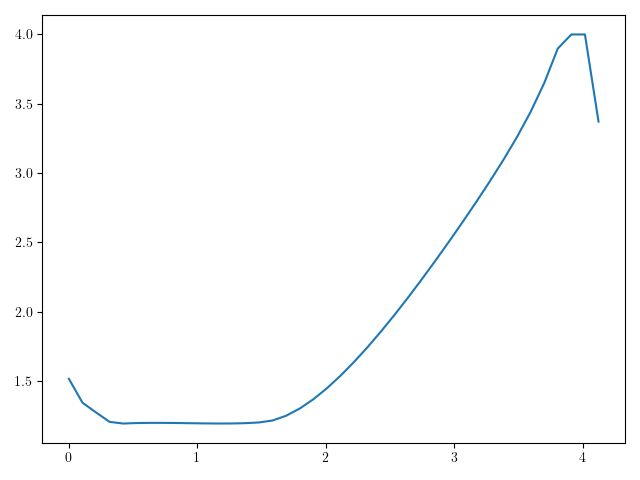

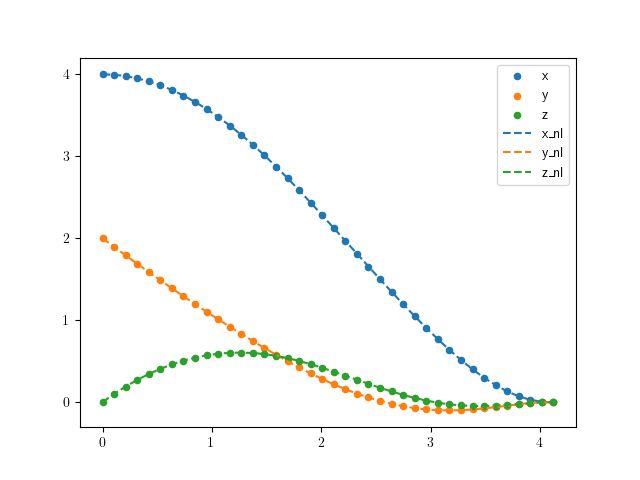

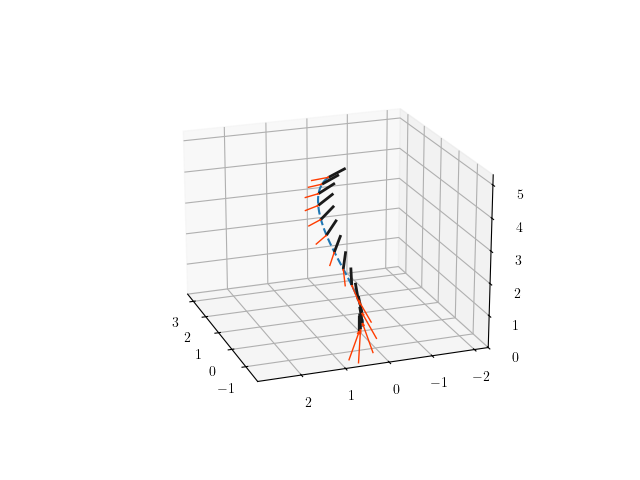

In [5]:
# Direction Cosine Matrix Function
def DCM(q): 
    return np.array(
        [
            [
                1 - 2 * (q[2] ** 2 + q[3] ** 2),
                2 * (q[1] * q[2] + q[0] * q[3]),
                2 * (q[1] * q[3] - q[0] * q[2]),
            ],
            [
                2 * (q[1] * q[2] - q[0] * q[3]),
                1 - 2 * (q[1] ** 2 + q[3] ** 2),
                2 * (q[2] * q[3] + q[0] * q[1]),
            ],
            [
                2 * (q[1] * q[3] + q[0] * q[2]),
                2 * (q[2] * q[3] - q[0] * q[1]),
                1 - 2 * (q[1] ** 2 + q[2] ** 2),
            ],
        ]
    )

import matplotlib.pyplot as plt
%matplotlib ipympl
matplotlib.rcParams['axes3d.mouserotationstyle'] = 'azel'

soln = scenario_data['standard']['mc_data'][0]['iters'][-1]

t_opt = soln['t_opt']
z_opt = soln['z_opt']
nu_opt = soln['nu_opt']

t_nl = soln['t_nl']
z_nl = soln['z_nl']
nu_nl = soln['nu_nl']

DCMs = np.empty((problem.method.N, 3, 3))
u_vecs = np.empty_like(nu_opt[:, :problem.model.m])
rt_I = np.zeros((problem.method.N, 3))
body_vecs = np.zeros((problem.method.N, 3))

veh = problem.mission.vehicle
rt = np.array([veh["rt1"], veh["rt2"], veh["rt3"]])

for i in range(problem.method.N):
    DCMs[i] = DCM(z_opt[i, 7:11])

    u_vecs[i] = 0.3* DCMs[i].T @ nu_opt[i, :problem.model.m]
    rt_I[i] = DCMs[i].T @ rt
    body_vecs[i] = 0.5 * DCMs[i].T @ np.array([1, 0, 0])

# # position plots
plt.figure()
plt.scatter(t_opt, z_opt[:, 1], label='x', s=20)
plt.scatter(t_opt, z_opt[:, 2], label='y', s=20)
plt.scatter(t_opt, z_opt[:, 3], label='z', s=20)

plt.plot(t_nl, z_nl[:, 1], label='x_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 2], label='y_nl', linestyle='--')
plt.plot(t_nl, z_nl[:, 3], label='z_nl', linestyle='--')
plt.legend()

skip = 3

# 3D position plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_nl[:, 2], z_nl[:, 3], z_nl[:, 1], linestyle='--')
ax.quiver3D(z_opt[::skip, 2], z_opt[::skip, 3], z_opt[::skip, 1], body_vecs[::skip, 1], body_vecs[::skip, 2], body_vecs[::skip, 0],
            normalize=False,
            arrow_length_ratio=0,
            color=(0.1, 0.1, 0.1),
            linewidth=2.0)

ax.quiver3D(z_opt[::skip, 2] - u_vecs[::skip, 1],
             z_opt[::skip, 3] - u_vecs[::skip, 2],
             z_opt[::skip, 1] - u_vecs[::skip, 0],
            u_vecs[::skip, 1], u_vecs[::skip, 2], u_vecs[::skip, 0],
            normalize=False,
            arrow_length_ratio=0.1,
            color=(1, 60/255, 0),
            linewidth=1)

# PLOT ASPECT RATIO FIXING (NEEDS TO BE DONE MANUALLY FOR 3D PLOTS :( )

# fix aspect ratio of 3d plot
x_lim = ax.get_xlim3d()
y_lim = ax.get_ylim3d()
z_lim = ax.get_zlim3d()

max_lim = max(abs(x_lim[1] - x_lim[0]), abs(y_lim[1] - y_lim[0]), abs(z_lim[1] - z_lim[0]))
x_mid = sum(x_lim) * 0.5
y_mid = sum(y_lim) * 0.5

ax.set_xlim3d([x_mid - max_lim * 0.5, x_mid + max_lim * 0.5])
ax.set_ylim3d([y_mid - max_lim * 0.5, y_mid + max_lim * 0.5])
ax.set_zlim3d([0, max_lim])

ax.view_init(elev=20, azim=160)

plt.figure()
plt.plot(t_opt, np.linalg.norm(nu_opt[:, :3], axis=1))

plt.tight_layout()
plt.show()


# Load data and preprocess... (compute loads...)

In [4]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
preProcess(PLTS1,problem);
    

# DASHBOARD

In [5]:
%load_ext autoreload
%autoreload 2

versions = ['methodvar'];
figpaths = ['figs/methodvar/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard','autotune'],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

## common pens to change
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};
PENS['standard']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS['autotune']  = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-','msty':'o','msz':3};

## weight pens (not currently in use)
# PENS['opt_weight']      = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_0']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_1']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.2,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_2']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.4,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_3']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.6,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_4']    = {'frgba':[.0,.0,.0,.1],'lrgba':[.8,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};
# PENS['opt_weight_5']    = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,1.,1.],'lw':1,'ls':'-'  ,'msty':'o','msz':3};

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



In [6]:
ALL_PLOTS = False

if ALL_PLOTS:
    makePlotCtrls(PLTS1,ins=plotparams);
    makePlotCtrls2(PLTS1,ins=plotparams);
    makePlotTrajs(PLTS1,ins=plotparams);
    makePlotStates(PLTS1,ins=plotparams);
    makePlotLoads(PLTS1,ins=plotparams);
    makePlotWghts(PLTS1,ins=plotparams);
    makePlotWghts2(PLTS1,ins=plotparams);
    makePlotWghts3(PLTS1,ins=plotparams);
    makePlotConvs(PLTS1,ins=plotparams);
    makePlotConvs2(PLTS1,ins=plotparams);

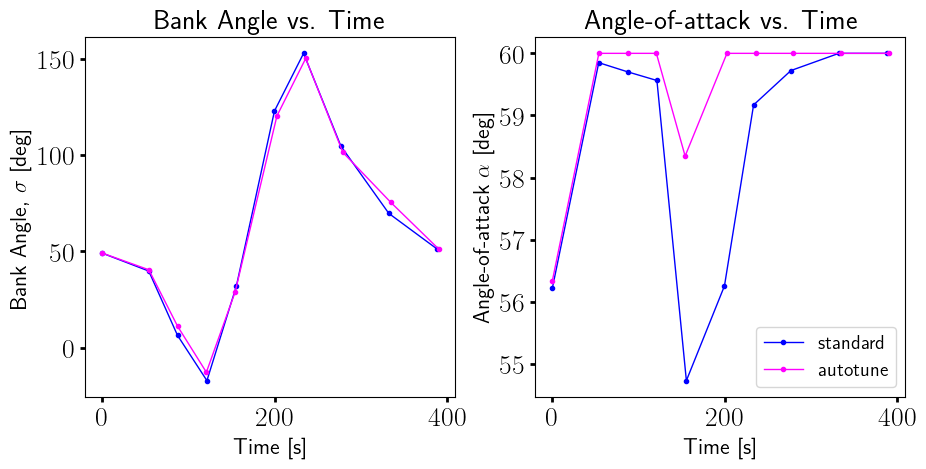

In [7]:
params = {}

grid = {};
grid[0] = [0.05,0.05,0.37,0.9]; grid[1] = [0.50,0.05,0.37,0.9];
params['grid'] = grid;

params['uselegend'] = [1];

makePlotCtrls2(PLTS1,ins={**plotparams,**params});

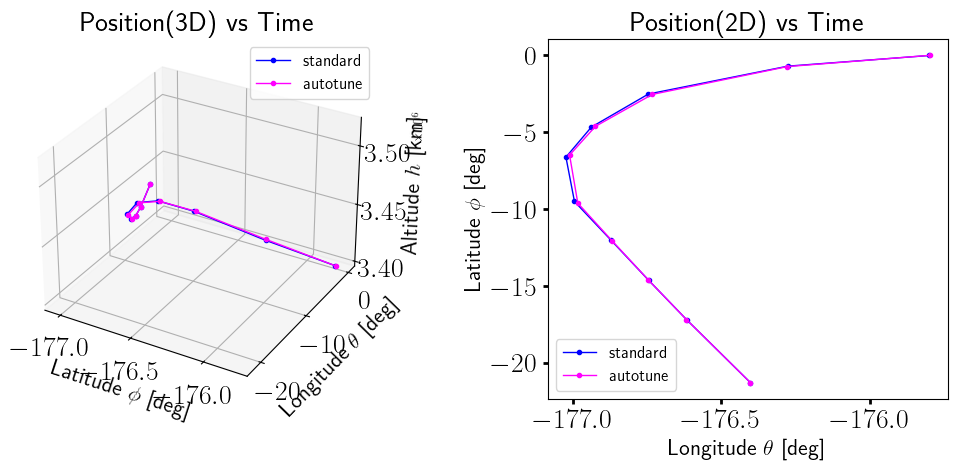

In [8]:
params = {}

grid = {};
grid[0] = [0.05,0.05,0.6,0.9]; grid[1] = [0.70,0.05,0.4,0.9];
params['grid'] = grid;

params['legendinfo'] = {'fontsize':12}

makePlotTrajs(PLTS1,ins={**plotparams,**params});

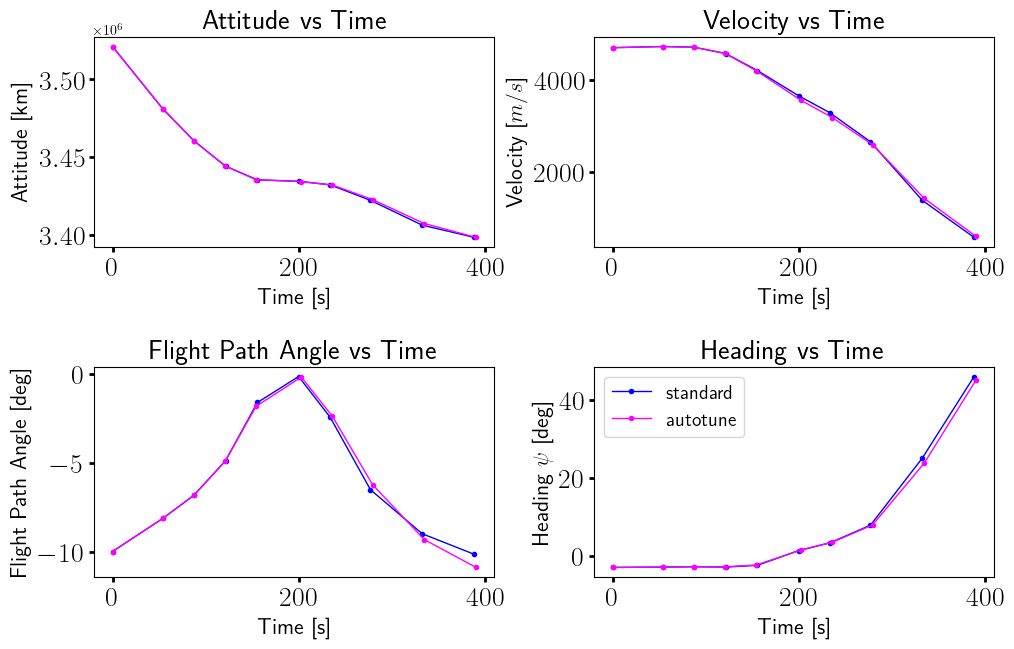

In [9]:
makePlotStates(PLTS1,ins=plotparams);

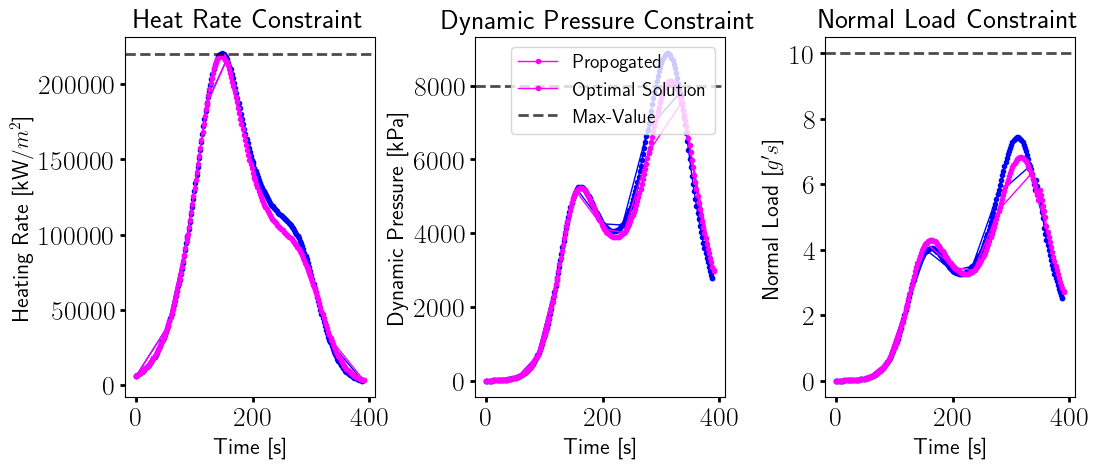

In [10]:
makePlotLoads(PLTS1,ins=plotparams);

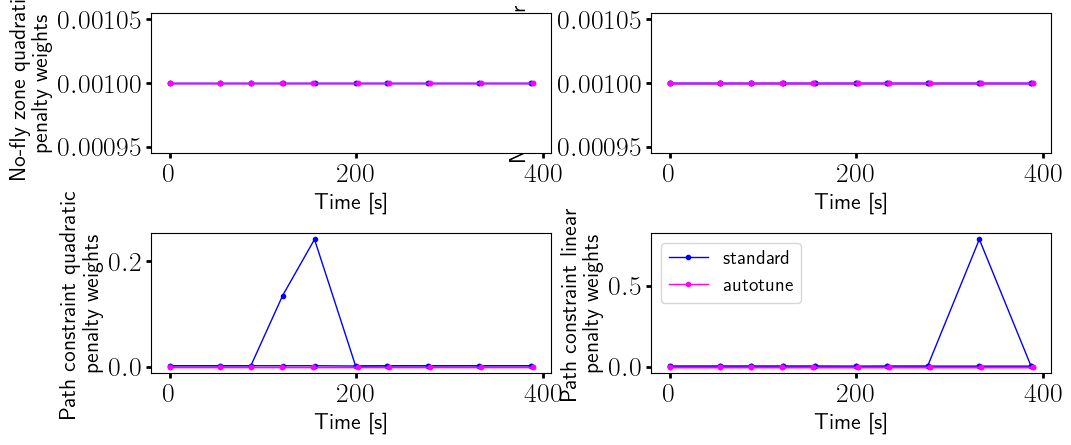

In [11]:
makePlotWghts(PLTS1,ins=plotparams);

IndexError: list index out of range

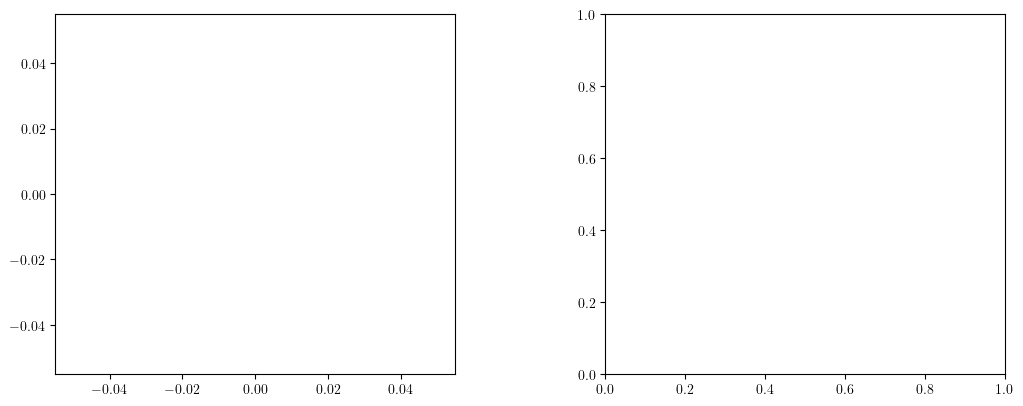

In [12]:
makePlotWghts2(PLTS1,ins=plotparams);

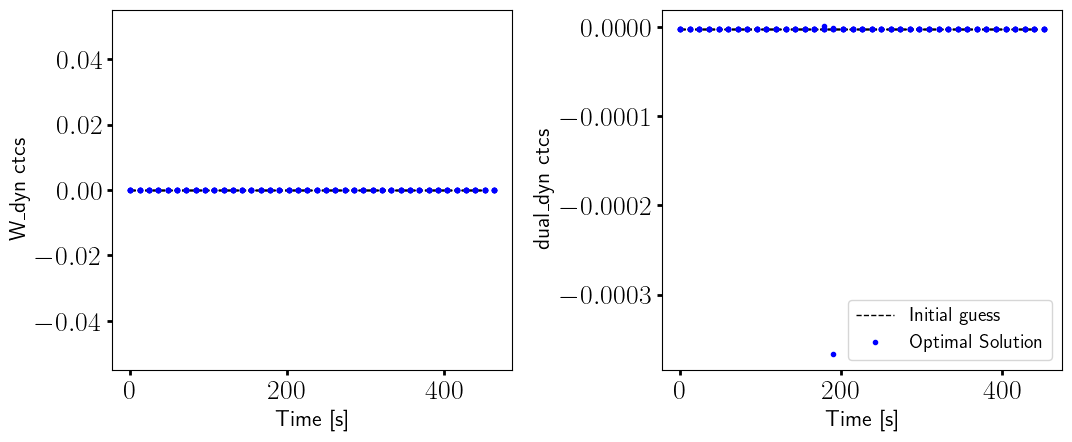

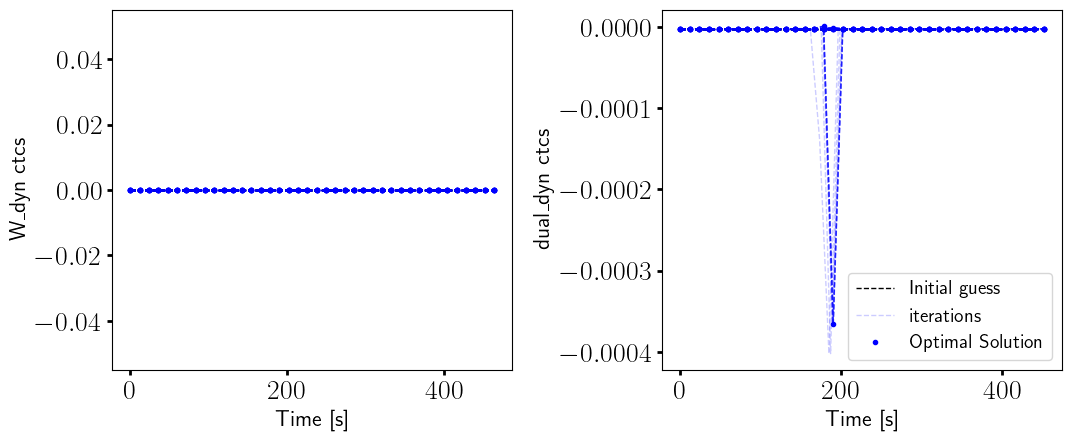

In [ ]:
makePlotWghts3(PLTS1,ins=plotparams);

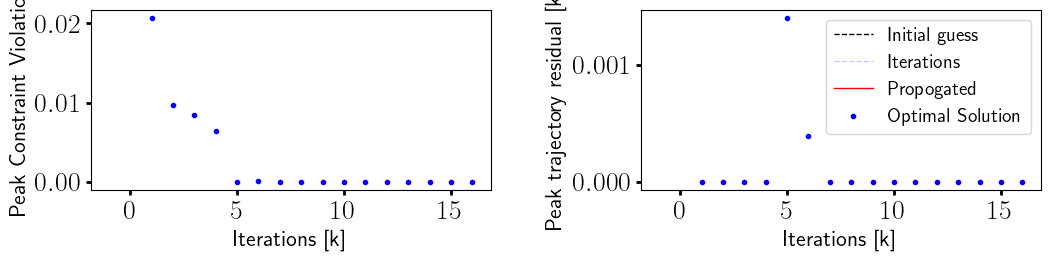

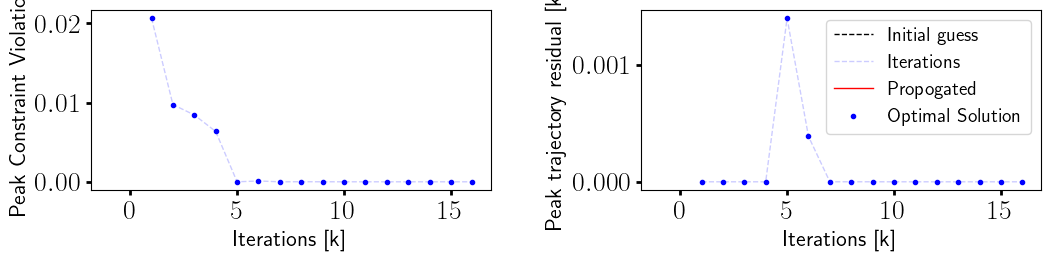

In [ ]:
makePlotConvs(PLTS1,ins=plotparams);

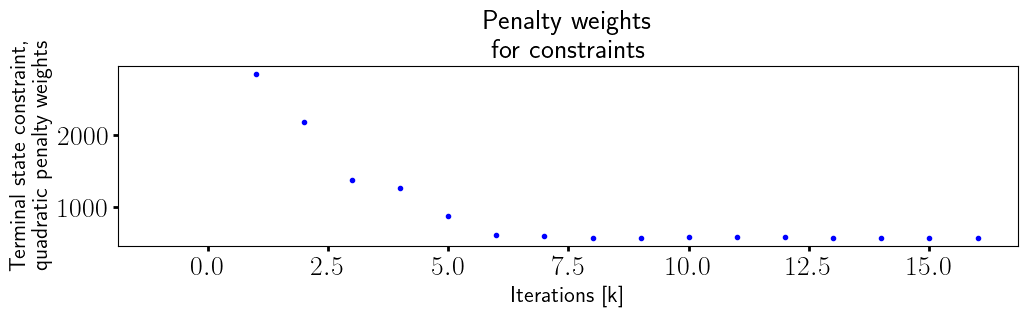

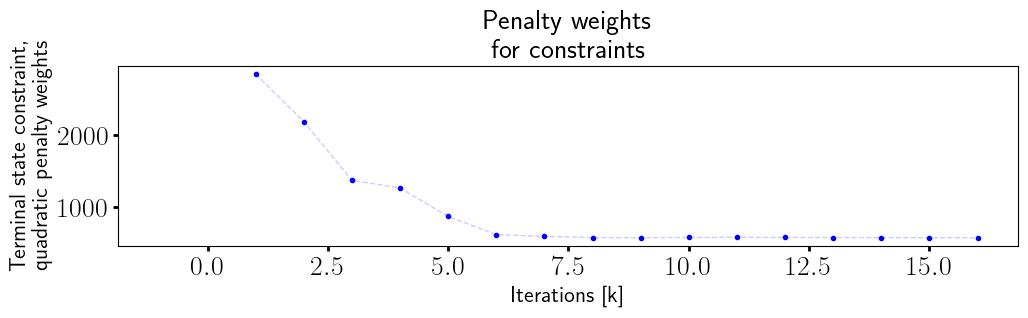

In [ ]:
makePlotConvs2(PLTS1,ins=plotparams);

# NOTES

In [ ]:
"""
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlotStates(PLTS1,ins={**plotparams,**params});
"""

"\nparams = {}\nfigsize = (10,5);\ngrid = {};\ngrid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];\ngrid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];\n   \ntitles = {};\nylabels = {};\nxlabels = {ind:'Time [s]' for ind in range(4)};\ntitles[0] = 'Attitude vs Time';\ntitles[1] = 'Velocity vs Time';\ntitles[2] = 'Flight Path Angle vs Time';\ntitles[3] = 'Heading vs Time';\n\nylabels[0] = 'Attitude [km]';\nylabels[1] = 'Velocity [$m/s$]';    \nylabels[2] = 'Flight Path Angle [deg]';\nylabels[3] = 'Heading $\\psi$ [deg]';\n\nparams['titleinfo'] = {'fontsize':20,}\nparams['xlabelinfo'] = {'fontsize':20}\nparams['ylabelinfo'] = {'fontsize':20}\n# params['ticksinfo'] = {'fontsize':20}\n# params['legendinfo'] = {'fontsize':2}\nparams['uselegend'] = [0,1,3];\n\nparams['figsize'] = figsize; params['grid'] = grid;\nparams['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;\nparams['displayfigs'] = True;\n\nmakePlotStates(PLTS1,ins={**plotparams,*